In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../Data/data_Denison_2018.csv')
df['Correct'] = (df['Stimulus'] == df['Response']).astype(int)

att_labels = {1: 'Valid', 2: 'Neutral', 3: 'Invalid'}
df['Attention_label'] = df['Attention'].map(att_labels)

df.head()

Matplotlib is building the font cache; this may take a moment.


,Subj_idx,Stimulus,Response,Confidence,RT_decConf,Attention,Orientation,Correct,Attention_label
0,1,1,1,1,0.276235,1,0.224658,1,Valid
1,1,2,1,2,1.754866,2,-6.965246,0,Neutral
2,1,2,2,2,1.232476,1,-8.439767,1,Valid
3,1,2,2,3,1.325371,1,-11.007351,1,Valid
4,1,1,1,2,1.165190,2,-2.968357,1,Neutral


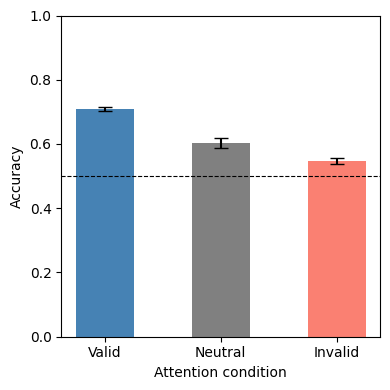

In [2]:
# Per-subject accuracy by attention condition
subj_acc = df.groupby(['Subj_idx', 'Attention'])['Correct'].mean().reset_index()

att_order = [1, 2, 3]
means = [subj_acc[subj_acc['Attention'] == a]['Correct'].mean() for a in att_order]
sems  = [subj_acc[subj_acc['Attention'] == a]['Correct'].sem()  for a in att_order]

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar([1, 2, 3], means, yerr=sems, capsize=5, color=['steelblue', 'gray', 'salmon'], width=0.5)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Valid', 'Neutral', 'Invalid'])
ax.set_xlabel('Attention condition')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

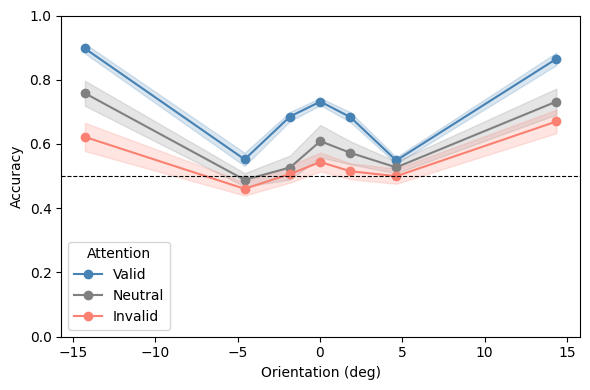

In [5]:
n_bins = 7
df['OriBin'] = pd.qcut(df['Orientation'], q=n_bins, duplicates='drop')
bin_centers = df.groupby('OriBin', observed=True)['Orientation'].mean()

# Per-subject mean accuracy per orientation bin x attention
subj_ori_acc = df.groupby(['Subj_idx', 'OriBin', 'Attention'], observed=True)['Correct'].mean().reset_index()

att_colors = {1: 'steelblue', 2: 'gray', 3: 'salmon'}

fig, ax = plt.subplots(figsize=(6, 4))
for att, label in att_labels.items():
    grp = subj_ori_acc[subj_ori_acc['Attention'] == att]
    stats = grp.groupby('OriBin', observed=True)['Correct'].agg(['mean', 'sem'])
    xs = bin_centers.values
    ax.plot(xs, stats['mean'].values, marker='o', label=label, color=att_colors[att])
    ax.fill_between(xs,
                    stats['mean'].values - stats['sem'].values,
                    stats['mean'].values + stats['sem'].values,
                    alpha=0.2, color=att_colors[att])

ax.axhline(0.5, color='k', linestyle='--', linewidth=0.8)
ax.set_xlabel('Orientation (deg)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend(title='Attention')
plt.tight_layout()
plt.show()

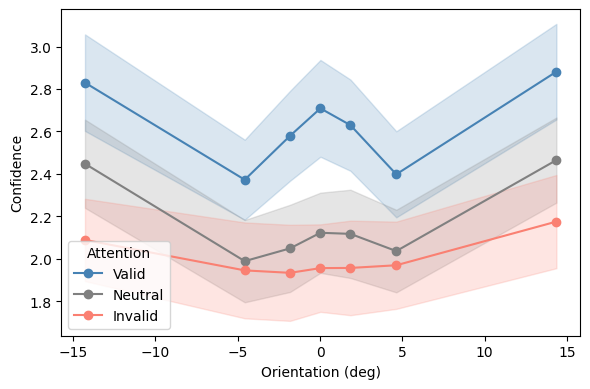

In [6]:
subj_ori_conf = df.groupby(['Subj_idx', 'OriBin', 'Attention'], observed=True)['Confidence'].mean().reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
for att, label in att_labels.items():
    grp = subj_ori_conf[subj_ori_conf['Attention'] == att]
    stats = grp.groupby('OriBin', observed=True)['Confidence'].agg(['mean', 'sem'])
    xs = bin_centers.values
    ax.plot(xs, stats['mean'].values, marker='o', label=label, color=att_colors[att])
    ax.fill_between(xs,
                    stats['mean'].values - stats['sem'].values,
                    stats['mean'].values + stats['sem'].values,
                    alpha=0.2, color=att_colors[att])

ax.set_xlabel('Orientation (deg)')
ax.set_ylabel('Confidence')
ax.legend(title='Attention')
plt.tight_layout()
plt.show()

In [9]:
# Create lagged variables within each subject (shift within subject groups)
df = df.sort_values(['Subj_idx']).copy()
for col in ['Stimulus', 'Response', 'Confidence', 'Attention', 'Orientation']:
    df[f'prev_{col}'] = df.groupby('Subj_idx')[col].shift(1)

# Drop first trial of each subject (no valid previous trial)
df_sd = df.dropna(subset=['prev_Stimulus']).copy()
df_sd['prev_Stimulus'] = df_sd['prev_Stimulus'].astype(int)
df_sd['prev_Response'] = df_sd['prev_Response'].astype(int)

# Serial choice bias: did current response match previous stimulus?
df_sd['choice_bias'] = (df_sd['Response'] == df_sd['prev_Response']).astype(int)

print(f"Trials for SD analysis: {len(df_sd)}")
df_sd[['Stimulus','Response','prev_Response','choice_bias','Attention']].head(8)

Trials for SD analysis: 24612


,Stimulus,Response,prev_Response,choice_bias,Attention
1079,1,1,1,1,2
2,2,2,1,0,1
3,2,2,2,1,1
4,1,1,2,0,2
5,1,1,1,1,1
6,2,1,1,1,3
7,1,1,1,1,3
8,2,1,1,1,1


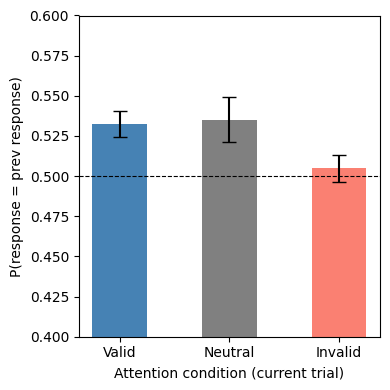

In [10]:
# Serial dependence in choice: P(response == prev_stimulus) by attention condition
subj_cb = df_sd.groupby(['Subj_idx', 'Attention'])['choice_bias'].mean().reset_index()

means = [subj_cb[subj_cb['Attention'] == a]['choice_bias'].mean() for a in att_order]
sems  = [subj_cb[subj_cb['Attention'] == a]['choice_bias'].sem()  for a in att_order]

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar([1, 2, 3], means, yerr=sems, capsize=5,
       color=['steelblue', 'gray', 'salmon'], width=0.5)
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.8, label='No bias')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Valid', 'Neutral', 'Invalid'])
ax.set_xlabel('Attention condition (current trial)')
ax.set_ylabel('P(response = prev response)')
ax.set_ylim(0.4, 0.6)
plt.tight_layout()
plt.show()

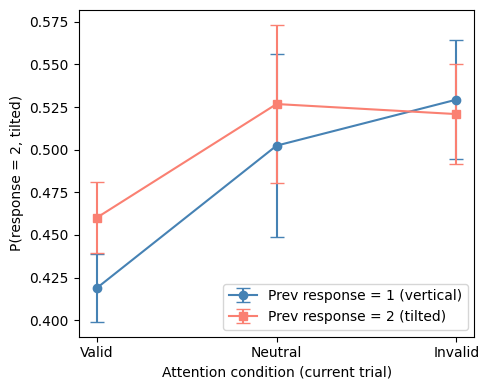

In [13]:
df_sd['resp2'] = (df_sd['Response'] == 2).astype(int)

subj_resp2 = df_sd.groupby(['Subj_idx', 'Attention', 'prev_Response'])['resp2'].mean().reset_index()

prev_resp_styles = {1: ('vertical', 'o', 'steelblue'), 2: ('tilted', 's', 'salmon')}

fig, ax = plt.subplots(figsize=(5, 4))
for prev_r, (label, marker, color) in prev_resp_styles.items():
    grp = subj_resp2[subj_resp2['prev_Response'] == prev_r]
    stats = grp.groupby('Attention')['resp2'].agg(['mean', 'sem'])
    xs = [1, 2, 3]
    ax.errorbar(xs, stats['mean'].values, yerr=stats['sem'].values,
                marker=marker, color=color, capsize=5, linewidth=1.5,
                label=f'Prev response = {prev_r} ({label})')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Valid', 'Neutral', 'Invalid'])
ax.set_xlabel('Attention condition (current trial)')
ax.set_ylabel('P(response = 2, tilted)')
ax.legend()
plt.tight_layout()
plt.show()

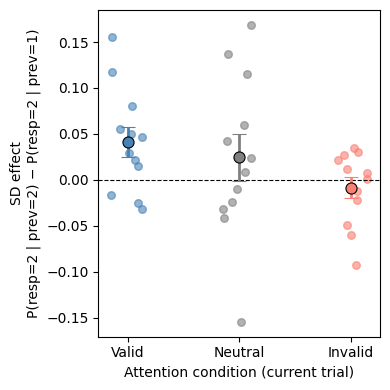

In [14]:
# SD effect per subject = P(resp=2 | prev=2) - P(resp=2 | prev=1)
pivot = subj_resp2.pivot_table(index=['Subj_idx', 'Attention'], columns='prev_Response', values='resp2').reset_index()
pivot.columns.name = None
pivot = pivot.rename(columns={1: 'prev1', 2: 'prev2'})
pivot['sd_effect'] = pivot['prev2'] - pivot['prev1']

rng = np.random.default_rng(0)
jitter = 0.15

fig, ax = plt.subplots(figsize=(4, 4))
for att in att_order:
    grp = pivot[pivot['Attention'] == att]['sd_effect']
    x = att
    # Individual points
    xs_jit = rng.uniform(x - jitter, x + jitter, size=len(grp))
    ax.scatter(xs_jit, grp.values, color=att_colors[att], alpha=0.6, s=30, zorder=2)
    # Group mean ± SEM
    ax.errorbar(x, grp.mean(), yerr=grp.sem(), color=att_colors[att],
                marker='o', markersize=8, capsize=5, linewidth=2, zorder=3,
                markeredgecolor='k', markeredgewidth=0.8)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_xticks(att_order)
ax.set_xticklabels(['Valid', 'Neutral', 'Invalid'])
ax.set_xlabel('Attention condition (current trial)')
ax.set_ylabel('SD effect\nP(resp=2 | prev=2) − P(resp=2 | prev=1)')
plt.tight_layout()
plt.show()

In [15]:
from scipy import stats

print(f"{'Attention':<10} {'Mean SD':>10} {'SEM':>8} {'t':>8} {'p':>10}")
print("-" * 50)
for att, label in att_labels.items():
    grp = pivot[pivot['Attention'] == att]['sd_effect']
    t, p = stats.ttest_1samp(grp, popmean=0)
    print(f"{label:<10} {grp.mean():>10.4f} {grp.sem():>8.4f} {t:>8.3f} {p:>10.4f}")

Attention     Mean SD      SEM        t          p
--------------------------------------------------
Valid          0.0413   0.0162    2.540     0.0275
Neutral        0.0244   0.0256    0.952     0.3616
Invalid       -0.0085   0.0117   -0.728     0.4820


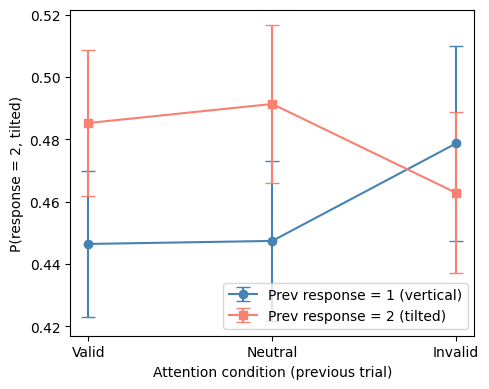

In [17]:
subj_resp2_prev = df_sd.groupby(['Subj_idx', 'prev_Attention', 'prev_Response'])['resp2'].mean().reset_index()
subj_resp2_prev['prev_Attention'] = subj_resp2_prev['prev_Attention'].astype(int)
subj_resp2_prev['prev_Response'] = subj_resp2_prev['prev_Response'].astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
for prev_r, (label, marker, color) in prev_resp_styles.items():
    grp = subj_resp2_prev[subj_resp2_prev['prev_Response'] == prev_r]
    stats_grp = grp.groupby('prev_Attention')['resp2'].agg(['mean', 'sem'])
    ax.errorbar([1, 2, 3], stats_grp['mean'].values, yerr=stats_grp['sem'].values,
                marker=marker, color=color, capsize=5, linewidth=1.5,
                label=f'Prev response = {prev_r} ({label})')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Valid', 'Neutral', 'Invalid'])
ax.set_xlabel('Attention condition (previous trial)')
ax.set_ylabel('P(response = 2, tilted)')
ax.legend()
plt.tight_layout()
plt.show()

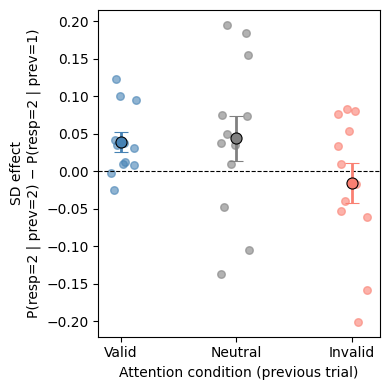

In [18]:
pivot_prev = subj_resp2_prev.pivot_table(
    index=['Subj_idx', 'prev_Attention'], columns='prev_Response', values='resp2'
).reset_index()
pivot_prev.columns.name = None
pivot_prev = pivot_prev.rename(columns={1: 'prev1', 2: 'prev2'})
pivot_prev['sd_effect'] = pivot_prev['prev2'] - pivot_prev['prev1']

fig, ax = plt.subplots(figsize=(4, 4))
for att in att_order:
    grp = pivot_prev[pivot_prev['prev_Attention'] == att]['sd_effect']
    x = att
    xs_jit = rng.uniform(x - jitter, x + jitter, size=len(grp))
    ax.scatter(xs_jit, grp.values, color=att_colors[att], alpha=0.6, s=30, zorder=2)
    ax.errorbar(x, grp.mean(), yerr=grp.sem(), color=att_colors[att],
                marker='o', markersize=8, capsize=5, linewidth=2, zorder=3,
                markeredgecolor='k', markeredgewidth=0.8)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_xticks(att_order)
ax.set_xticklabels(['Valid', 'Neutral', 'Invalid'])
ax.set_xlabel('Attention condition (previous trial)')
ax.set_ylabel('SD effect\nP(resp=2 | prev=2) − P(resp=2 | prev=1)')
plt.tight_layout()
plt.show()

In [19]:
print(f"{'Attention':<10} {'Mean SD':>10} {'SEM':>8} {'t':>8} {'p':>10}")
print("-" * 50)
for att, label in att_labels.items():
    grp = pivot_prev[pivot_prev['prev_Attention'] == att]['sd_effect']
    t, p = stats.ttest_1samp(grp, popmean=0)
    print(f"{label:<10} {grp.mean():>10.4f} {grp.sem():>8.4f} {t:>8.3f} {p:>10.4f}")

Attention     Mean SD      SEM        t          p
--------------------------------------------------
Valid          0.0388   0.0130    2.981     0.0125
Neutral        0.0440   0.0303    1.451     0.1747
Invalid       -0.0159   0.0267   -0.595     0.5639
